# Exploratory Data Analysis

In [738]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_ratings, load_movies, load_users

In [739]:
FIGURE_SIZE_STANDARD = (8, 4)
FIGURE_SIZE_LARGE = (10, 8)
FIGURE_SIZE_SQUARE = (5, 5)

COLOR_PRIMARY = "steelblue"
COLOR_SECONDARY = "slategray"
COLOR_ACCENT = "firebrick"
COLOR_HIGHLIGHT = "darkorange"

In [740]:
ratings = load_ratings()
movies = load_movies()
users = load_users()

pd.DataFrame({
    "Dataset": ["Ratings", "Movies", "Users"],
    "Rows": [ratings.shape[0], movies.shape[0], users.shape[0]],
    "Columns": [ratings.shape[1], movies.shape[1], users.shape[1]]
})

Loaded 1000209 ratings from c:\Users\Mykyta\Projects\ucu-recsys\experiments\..\data\ml-1m\ratings.dat
Loaded 3883 movies from c:\Users\Mykyta\Projects\ucu-recsys\experiments\..\data\ml-1m\movies.dat
Loaded 6040 users from c:\Users\Mykyta\Projects\ucu-recsys\experiments\..\data\ml-1m\users.dat


,Dataset,Rows,Columns
0,Ratings,1000209,4
1,Movies,3883,3
2,Users,6040,5


In [741]:
ratings.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [742]:
movies.head()

,item_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [743]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## Section 2: Data Integrity Checks

In [744]:
user_id_density = ratings["user_id"].max() / ratings["user_id"].nunique()
item_id_density = ratings["item_id"].max() / ratings["item_id"].nunique()

items_with_ratings = set(ratings["item_id"].unique())
all_movie_ids = set(movies["item_id"].unique())
ghost_items = all_movie_ids - items_with_ratings

users_with_ratings = set(ratings["user_id"].unique())
all_user_ids = set(users["user_id"].unique())
orphan_users = all_user_ids - users_with_ratings

pd.DataFrame([
    {"Check": "User ID Density", "Value": f"{user_id_density:.4f}"},
    {"Check": "Item ID Density", "Value": f"{item_id_density:.4f}"},
    {"Check": "Ghost Items (no ratings)", "Value": f"{len(ghost_items):,}"},
    {"Check": "Orphan Users (no ratings)", "Value": f"{len(orphan_users):,}"},
])

,Check,Value
0,User ID Density,1.0000
1,Item ID Density,1.0664
2,Ghost Items (no ratings),177
3,Orphan Users (no ratings),0


**Takeaway:** The integrity checks show a clean dataset from the user side. Every user in the users table has at least one rating, and user IDs form a continuous sequence. However, 177 movies in the catalog have zero ratings, creating "ghost items" that need special handling. These items cannot be recommended by any collaborative filtering method because there is no interaction signal. However, they can still be included in content-based recommendations if we use their genre metadata.

For practical modeling, we can build user-item matrices without worrying about orphan users. The ghost items should either be excluded from evaluation since they have no ground truth, or they should be handled explicitly through content-based fallback strategies. This is a minor data quality issue, but it's worth noting that in production systems, new items with no ratings are common. Our content-based component will need to handle these cold items.

## Section 3: Interaction Sparsity Analysis

In [745]:
user_count = ratings["user_id"].nunique()
item_count = ratings["item_id"].nunique()
rating_count = len(ratings)

total_possible = user_count * item_count
density = rating_count / total_possible
sparsity = 1 - density

pd.DataFrame([
    {"Metric": "Users", "Value": f"{user_count:,}"},
    {"Metric": "Items", "Value": f"{item_count:,}"},
    {"Metric": "Ratings", "Value": f"{rating_count:,}"},
    {"Metric": "Possible Entries", "Value": f"{total_possible:,}"},
    {"Metric": "Density", "Value": f"{density:.4%}"},
    {"Metric": "Sparsity", "Value": f"{sparsity:.4%}"},
])

,Metric,Value
0,Users,"6,040"
1,Items,"3,706"
2,Ratings,"1,000,209"
3,Possible Entries,"22,384,240"
4,Density,4.4684%
5,Sparsity,95.5316%


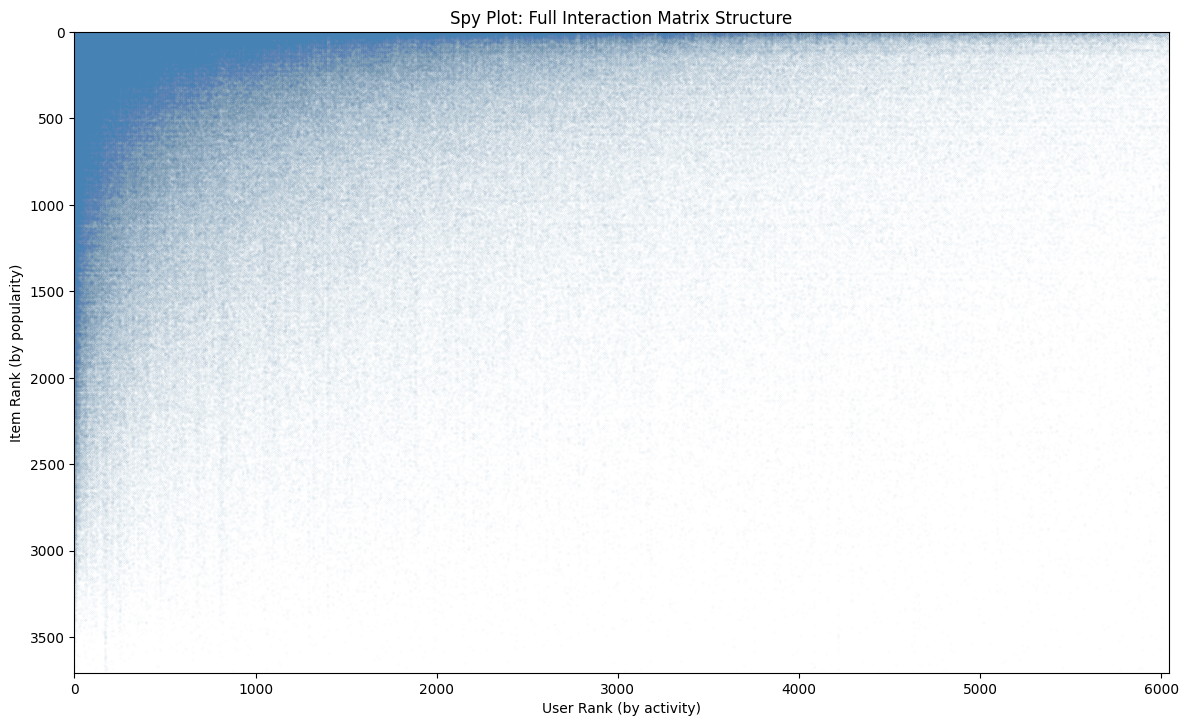

In [746]:
user_rank = {user: rank for rank, user in enumerate(
    ratings.groupby("user_id").size().sort_values(ascending=False).index
)}
item_rank = {item: rank for rank, item in enumerate(
    ratings.groupby("item_id").size().sort_values(ascending=False).index
)}

plot_data = ratings.copy()
plot_data["user_rank"] = plot_data["user_id"].map(user_rank)
plot_data["item_rank"] = plot_data["item_id"].map(item_rank)

aspect_ratio = len(user_rank) / len(item_rank)
figure_width = 12
figure_height = figure_width / aspect_ratio

figure, axis = plt.subplots(figsize=(figure_width, figure_height))
axis.scatter(
    plot_data["user_rank"],
    plot_data["item_rank"],
    s=0.001,
    alpha=0.5,
    c=COLOR_PRIMARY,
    rasterized=True
)
axis.set_xlabel("User Rank (by activity)")
axis.set_ylabel("Item Rank (by popularity)")
axis.set_title("Spy Plot: Full Interaction Matrix Structure")
axis.set_xlim(0, len(user_rank))
axis.set_ylim(len(item_rank), 0)
plt.tight_layout()
plt.show()

In [747]:
np.random.seed(42)
sample_user_ids = np.random.choice(
    ratings["user_id"].unique(),
    size=1000,
    replace=False
)

user_items = ratings[ratings["user_id"].isin(sample_user_ids)].groupby("user_id")["item_id"].apply(set)

overlaps = []
for _ in range(5000):
    user_a, user_b = np.random.choice(
        sample_user_ids,
        2,
        replace=False
    )
    if user_a in user_items.index and user_b in user_items.index:
        overlap = len(user_items[user_a] & user_items[user_b])
        overlaps.append(overlap)

overlaps = np.array(overlaps)

pd.DataFrame([
    {"Metric": "Mean Items in Common", "Value": f"{overlaps.mean():.2f}"},
    {"Metric": "Median Items in Common", "Value": f"{np.median(overlaps):.1f}"},
    {"Metric": "Max Items in Common", "Value": f"{overlaps.max()}"},
    {"Metric": "Pairs with 0 Overlap", "Value": f"{(overlaps == 0).mean():.1%}"},
    {"Metric": "Pairs with < 5 Overlap", "Value": f"{(overlaps < 5).mean():.1%}"},
])

,Metric,Value
0,Mean Items in Common,21.18
1,Median Items in Common,9.0
2,Max Items in Common,376
3,Pairs with 0 Overlap,5.2%
4,Pairs with < 5 Overlap,30.7%


**Takeaway:** The sparsity analysis shows a difficult situation for collaborative filtering. With only 4.47% of the user-item matrix filled, we have very little direct overlap between users. The spy plot illustrates this clearly: even after sorting by activity and popularity, the interaction matrix is mostly empty. The user overlap statistics are particularly concerning; nearly a third of randomly sampled user pairs share fewer than 5 items in common. This makes it hard to compute reliable similarity.

This sparsity shapes our approach. Pure memory-based collaborative filtering, which calculates similarities directly from the sparse matrix, will have trouble with inaccurate estimates for users who share few items. Matrix factorization methods are appealing because they can generalize across sparse entries by learning dense representations. When we use user-user or item-item collaborative filtering, we should think about setting minimum overlap thresholds for computing similarity. We should also expect that these methods may not perform well for users or items with limited interaction history.

## Section 4: User and Item Activity Distributions

In [748]:
user_activity = ratings.groupby("user_id").size()
item_popularity = ratings.groupby("item_id").size()
user_average_rating = ratings.groupby("user_id")["rating"].mean()
item_average_rating = ratings.groupby("item_id")["rating"].mean()
user_rating_std = ratings.groupby("user_id")["rating"].std().fillna(0)

global_mean_rating = ratings["rating"].mean()

pd.DataFrame({
    "Metric": ["Min", "Max", "Mean", "Median", "Std"],
    "User Activity": [
        user_activity.min(),
        user_activity.max(),
        f"{user_activity.mean():.1f}",
        f"{user_activity.median():.1f}",
        f"{user_activity.std():.1f}"
    ],
    "Item Popularity": [
        item_popularity.min(),
        item_popularity.max(),
        f"{item_popularity.mean():.1f}",
        f"{item_popularity.median():.1f}",
        f"{item_popularity.std():.1f}"
    ],
})

,Metric,User Activity,Item Popularity
0,Min,20,1
1,Max,2314,3428
2,Mean,165.6,269.9
3,Median,96.0,123.5
4,Std,192.7,384.0


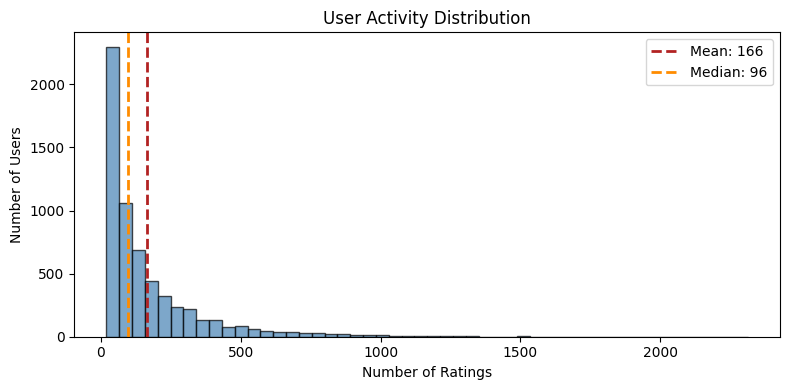

In [749]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    user_activity,
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.axvline(
    user_activity.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {user_activity.mean():.0f}"
)
axis.axvline(
    user_activity.median(),
    color=COLOR_HIGHLIGHT,
    linestyle="--",
    linewidth=2,
    label=f"Median: {user_activity.median():.0f}"
)
axis.set_xlabel("Number of Ratings")
axis.set_ylabel("Number of Users")
axis.set_title("User Activity Distribution")
axis.legend()

plt.tight_layout()
plt.show()

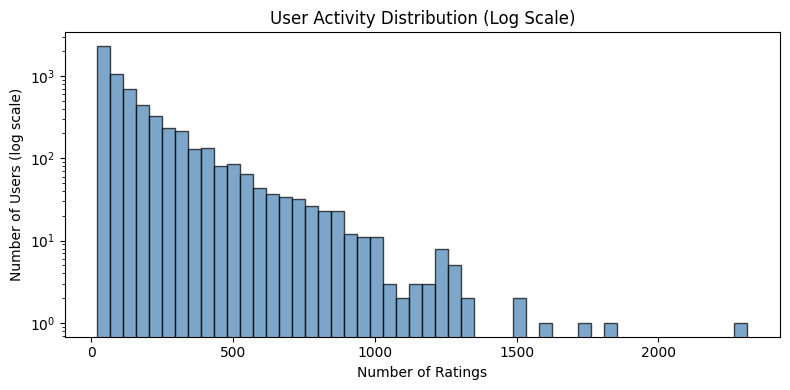

In [750]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    user_activity,
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.set_yscale("log")
axis.set_xlabel("Number of Ratings")
axis.set_ylabel("Number of Users (log scale)")
axis.set_title("User Activity Distribution (Log Scale)")

plt.tight_layout()
plt.show()

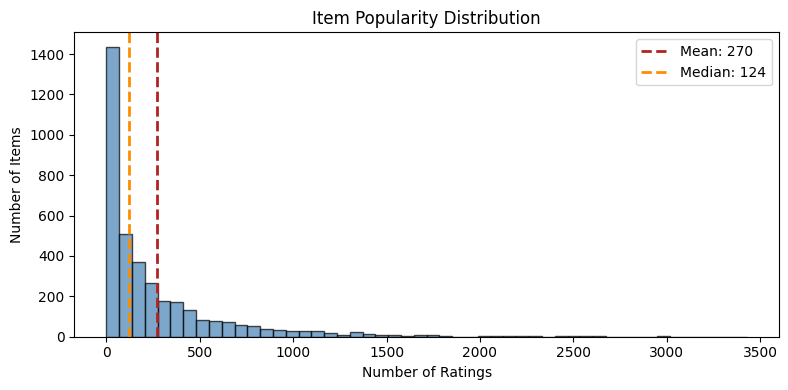

In [751]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    item_popularity,
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.axvline(
    item_popularity.mean(),
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {item_popularity.mean():.0f}"
)
axis.axvline(
    item_popularity.median(),
    color=COLOR_HIGHLIGHT,
    linestyle="--",
    linewidth=2,
    label=f"Median: {item_popularity.median():.0f}"
)
axis.set_xlabel("Number of Ratings")
axis.set_ylabel("Number of Items")
axis.set_title("Item Popularity Distribution")
axis.legend()

plt.tight_layout()
plt.show()

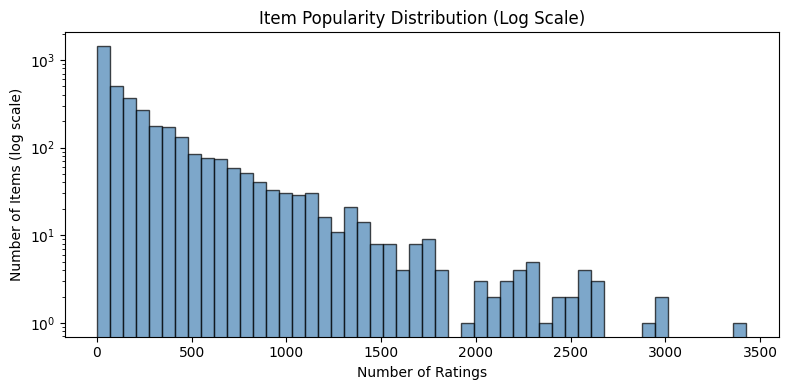

In [752]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    item_popularity,
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.set_yscale("log")
axis.set_xlabel("Number of Ratings")
axis.set_ylabel("Number of Items (log scale)")
axis.set_title("Item Popularity Distribution (Log Scale)")

plt.tight_layout()
plt.show()

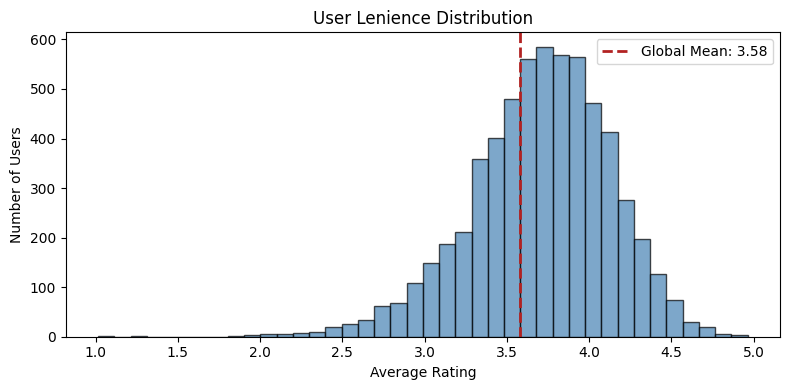

In [753]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    user_average_rating,
    bins=40,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.axvline(
    global_mean_rating,
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Global Mean: {global_mean_rating:.2f}"
)
axis.set_xlabel("Average Rating")
axis.set_ylabel("Number of Users")
axis.set_title("User Lenience Distribution")
axis.legend()

plt.tight_layout()
plt.show()

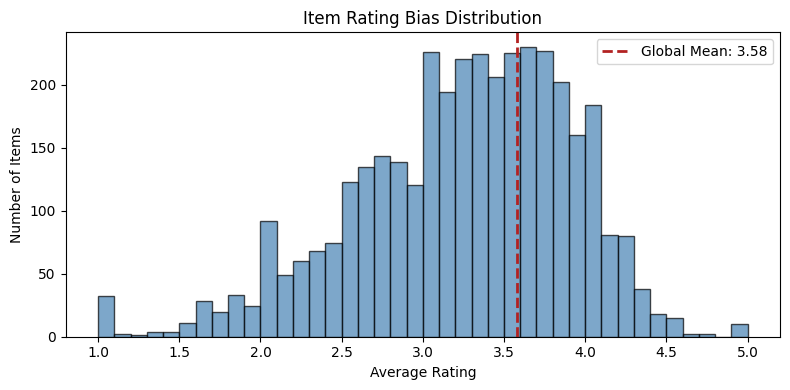

In [754]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    item_average_rating,
    bins=40,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.axvline(
    global_mean_rating,
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label=f"Global Mean: {global_mean_rating:.2f}"
)
axis.set_xlabel("Average Rating")
axis.set_ylabel("Number of Items")
axis.set_title("Item Rating Bias Distribution")
axis.legend()

plt.tight_layout()
plt.show()

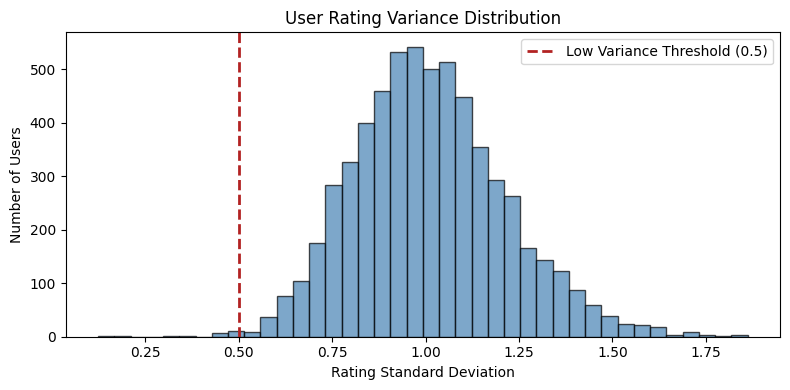

In [755]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    user_rating_std,
    bins=40,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)
axis.axvline(
    0.5,
    color=COLOR_ACCENT,
    linestyle="--",
    linewidth=2,
    label="Low Variance Threshold (0.5)"
)
axis.set_xlabel("Rating Standard Deviation")
axis.set_ylabel("Number of Users")
axis.set_title("User Rating Variance Distribution")
axis.legend()

plt.tight_layout()
plt.show()

In [783]:
zero_variance_users = user_rating_std[user_rating_std == 0]
low_variance_users = user_rating_std[user_rating_std < 0.5]

zero_variance_details = ratings[ratings["user_id"].isin(zero_variance_users.index)].groupby("user_id").agg({
    "rating": ["count", "mean"]
})
zero_variance_details.columns = ["rating_count", "constant_rating"]
zero_variance_details = zero_variance_details.sort_values(
    by="rating_count",
    ascending=False
)

pd.DataFrame([
    {"Metric": "Zero-Variance Users (std = 0)", "Count": len(zero_variance_users), "Percentage": f"{len(zero_variance_users) / user_count:.2%}"},
    {"Metric": "Low-Variance Users (std < 0.5)", "Count": len(low_variance_users), "Percentage": f"{len(low_variance_users) / user_count:.2%}"},
])

,Metric,Count,Percentage
0,Zero-Variance Users (std = 0),0,0.00%
1,Low-Variance Users (std < 0.5),17,0.28%


**Takeaway:** The activity distributions confirm our suspicions. Both users and items display heavily right-skewed behavior, with means much higher than medians. Some users have rated over 2,000 movies, while the typical user rates around 96. That’s a 20-fold difference. Similarly, item popularity varies from a single rating to over 3,400. This variation means it would be simplistic to treat all users and items the same way.

For modeling, this strongly suggests we should include user and item bias terms. The distribution of user ratings shows that some users consistently rate higher or lower than average. We need to capture these individual baselines explicitly instead of hoping the latent factors will learn them. The good news is that we have very few "problematic" users. Only 0.28% show low rating variance, which means most users provide a clear signal across their ratings. When we build our recommenders, we will include bias terms in all matrix factorization methods. For similarity-based approaches, we might want to mean-center ratings per user to address differences in lenience.

## Section 5: Data Pathologies

### Pathology #1: Popularity Skew (Long-Tail Distribution)

In [757]:
def compute_gini_coefficient(values):
    sorted_values = np.sort(values)
    count = len(sorted_values)
    numerator = 2 * np.sum((np.arange(1, count + 1) * sorted_values))
    denominator = count * np.sum(sorted_values)
    return numerator / denominator - (count + 1) / count

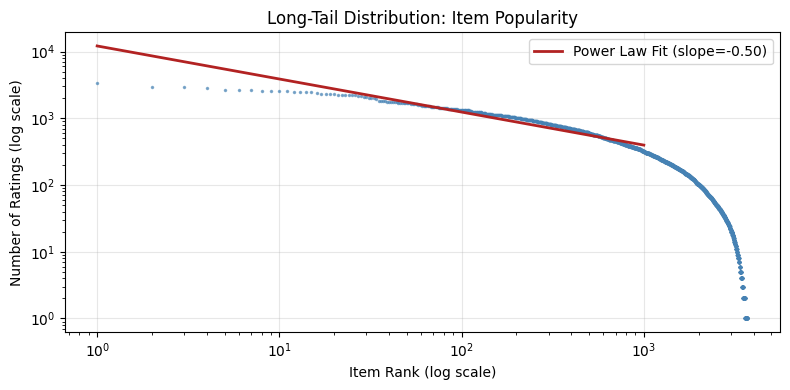

In [758]:
item_counts = ratings.groupby("item_id").size().sort_values(ascending=False).reset_index(drop=True)
item_counts.index = item_counts.index + 1

log_rank = np.log(item_counts.index[:1000])
log_frequency = np.log(item_counts.values[:1000])
slope, intercept = np.polyfit(
    log_rank,
    log_frequency,
    1
)

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.loglog(
    item_counts.index,
    item_counts.values,
    ".",
    markersize=3,
    alpha=0.6,
    color=COLOR_PRIMARY
)

fit_x = np.array([1, 1000])
fit_y = np.exp(intercept) * fit_x ** slope
axis.plot(
    fit_x,
    fit_y,
    "-",
    linewidth=2,
    color=COLOR_ACCENT,
    label=f"Power Law Fit (slope={slope:.2f})"
)

axis.set_xlabel("Item Rank (log scale)")
axis.set_ylabel("Number of Ratings (log scale)")
axis.set_title("Long-Tail Distribution: Item Popularity")
axis.legend()
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

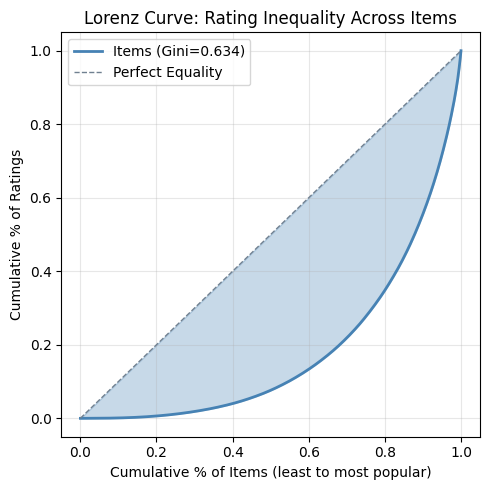

In [759]:
item_gini = compute_gini_coefficient(item_popularity.values)
user_gini = compute_gini_coefficient(user_activity.values)

sorted_items = np.sort(item_popularity.values)
cumulative_ratings = np.cumsum(sorted_items) / np.sum(sorted_items)
cumulative_items = np.arange(1, len(sorted_items) + 1) / len(sorted_items)

figure, axis = plt.subplots(figsize=FIGURE_SIZE_SQUARE)

axis.plot(
    cumulative_items,
    cumulative_ratings,
    linewidth=2,
    color=COLOR_PRIMARY,
    label=f"Items (Gini={item_gini:.3f})"
)
axis.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1,
    color=COLOR_SECONDARY,
    label="Perfect Equality"
)
axis.fill_between(
    cumulative_items,
    cumulative_ratings,
    cumulative_items,
    alpha=0.3,
    color=COLOR_PRIMARY
)

axis.set_xlabel("Cumulative % of Items (least to most popular)")
axis.set_ylabel("Cumulative % of Ratings")
axis.set_title("Lorenz Curve: Rating Inequality Across Items")
axis.legend(loc="upper left")
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [760]:
top_rated_items = item_popularity.nlargest(20)
top_one_percent_count = int(len(item_popularity) * 0.01)
top_one_percent_ratings = item_popularity.nlargest(top_one_percent_count).sum()

top_items_table = top_rated_items.reset_index()
top_items_table.columns = ["item_id", "rating_count"]
top_items_table = top_items_table.merge(
    movies[["item_id", "title"]],
    on="item_id"
)
top_items_table["percent_of_total"] = (top_items_table["rating_count"] / rating_count * 100).round(2)
top_items_table

,item_id,rating_count,title,percent_of_total
0,2858,3428,American Beauty (1999),0.34
1,260,2991,Star Wars: Episode IV - A New Hope (1977),0.30
2,1196,2990,Star Wars: Episode V - The Empire Strikes Back...,0.30
3,1210,2883,Star Wars: Episode VI - Return of the Jedi (1983),0.29
4,480,2672,Jurassic Park (1993),0.27
5,2028,2653,Saving Private Ryan (1998),0.27
6,589,2649,Terminator 2: Judgment Day (1991),0.26
7,2571,2590,"Matrix, The (1999)",0.26
8,1270,2583,Back to the Future (1985),0.26
9,593,2578,"Silence of the Lambs, The (1991)",0.26


**Takeaway:** The popularity skew in this dataset is severe and follows a classic power-law distribution. The top 20 movies, mostly blockbusters like Star Wars, American Beauty, and Jurassic Park, dominate interactions, while niche films struggle for attention. With a Gini coefficient showing high inequality, any model we build will tend to recommend popular items, as most of the training signal comes from them.

This has direct implications for evaluation and deployment. Standard accuracy metrics, like RMSE and precision, will focus on popular items, potentially hiding poor performance on niche films. We should consider using popularity-stratified evaluation to understand how the model behaves across different item segments. More fundamentally, if we deploy a model trained on this data without adjustments, it will likely reinforce existing popularity bias by recommending blockbusters to everyone. Depending on our business goals, this may be acceptable, or it could undermine personalization.

### Pathology #2: Cold-Start Problem

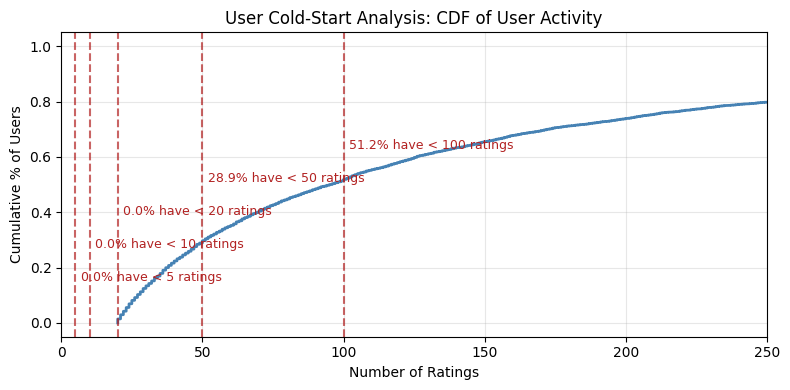

In [761]:
sorted_activity = np.sort(user_activity.values)
user_cdf = np.arange(1, len(sorted_activity) + 1) / len(sorted_activity)

thresholds = [5, 10, 20, 50, 100]

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.plot(
    sorted_activity,
    user_cdf,
    linewidth=2,
    color=COLOR_PRIMARY
)

for index, threshold in enumerate(thresholds):
    percentage = (user_activity < threshold).mean() * 100
    axis.axvline(
        threshold,
        color=COLOR_ACCENT,
        linestyle="--",
        alpha=0.7
    )
    axis.text(
        threshold + 2,
        0.15 + index * 0.12,
        f"{percentage:.1f}% have < {threshold} ratings",
        fontsize=9,
        color=COLOR_ACCENT
    )

axis.set_xlabel("Number of Ratings")
axis.set_ylabel("Cumulative % of Users")
axis.set_title("User Cold-Start Analysis: CDF of User Activity")
axis.set_xlim(0, 250)
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

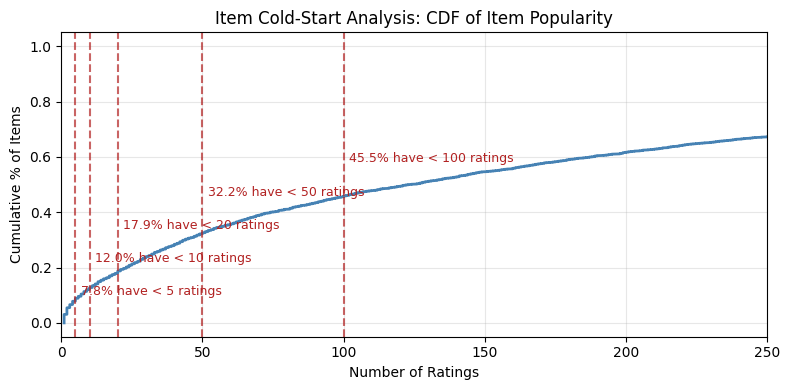

In [762]:
sorted_popularity = np.sort(item_popularity.values)
item_cdf = np.arange(1, len(sorted_popularity) + 1) / len(sorted_popularity)

thresholds = [5, 10, 20, 50, 100]

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.plot(
    sorted_popularity,
    item_cdf,
    linewidth=2,
    color=COLOR_PRIMARY
)

for index, threshold in enumerate(thresholds):
    percentage = (item_popularity < threshold).mean() * 100
    axis.axvline(
        threshold,
        color=COLOR_ACCENT,
        linestyle="--",
        alpha=0.7
    )
    axis.text(
        threshold + 2,
        0.10 + index * 0.12,
        f"{percentage:.1f}% have < {threshold} ratings",
        fontsize=9,
        color=COLOR_ACCENT
    )

axis.set_xlabel("Number of Ratings")
axis.set_ylabel("Cumulative % of Items")
axis.set_title("Item Cold-Start Analysis: CDF of Item Popularity")
axis.set_xlim(0, 250)
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [763]:
def categorize_user_by_activity(activity):
    if activity < 20:
        return "Cold (<20)"
    elif activity < 100:
        return "Warm (20-99)"
    else:
        return "Active (100+)"


def categorize_item_by_popularity(popularity):
    if popularity < 10:
        return "Cold (<10)"
    elif popularity < 50:
        return "Warm (10-49)"
    else:
        return "Popular (50+)"


user_segments = user_activity.apply(categorize_user_by_activity).value_counts()
item_segments = item_popularity.apply(categorize_item_by_popularity).value_counts()

user_segment_data = []
for segment in ["Cold (<20)", "Warm (20-99)", "Active (100+)"]:
    count = user_segments.get(segment, 0)
    user_segment_data.append({
        "Segment": segment,
        "Count": count,
        "Percentage": f"{count / user_count * 100:.1f}%"
    })

item_segment_data = []
for segment in ["Cold (<10)", "Warm (10-49)", "Popular (50+)"]:
    count = item_segments.get(segment, 0)
    item_segment_data.append({
        "Segment": segment,
        "Count": count,
        "Percentage": f"{count / item_count * 100:.1f}%"
    })

display(pd.DataFrame(user_segment_data))
display(pd.DataFrame(item_segment_data))

,Segment,Count,Percentage
0,Cold (<20),0,0.0%
1,Warm (20-99),3095,51.2%
2,Active (100+),2945,48.8%


,Segment,Count,Percentage
0,Cold (<10),446,12.0%
1,Warm (10-49),746,20.1%
2,Popular (50+),2514,67.8%


**Takeaway:** The cold-start analysis shows an important imbalance. While 12% of items are truly cold, with fewer than 10 ratings, there are no cold users in this dataset. This is due to the MovieLens 1M curation process, which required users to rate at least 20 movies to be included. Real-world systems constantly deal with user cold-start every time someone signs up. Thus, we should be careful about saying our models "solve" cold-start when based on this dataset alone.

For our experiments, item cold-start is a more urgent issue. Collaborative filtering will have a hard time with the approximately 450 items that have fewer than 10 ratings. This makes content-based approaches vital as a backup. When we evaluate models, we should report performance separately for popular and cold items. This will help us see where each method succeeds or fails.

## Section 6: Temporal Dynamics

In [764]:
ratings["datetime"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)
ratings["year"] = ratings["datetime"].dt.year
ratings["month"] = ratings["datetime"].dt.to_period("M")

time_span = ratings["datetime"].max() - ratings["datetime"].min()

pd.DataFrame([
    {"Metric": "First Rating", "Value": str(ratings["datetime"].min())},
    {"Metric": "Last Rating", "Value": str(ratings["datetime"].max())},
    {"Metric": "Time Span (days)", "Value": f"{time_span.days}"},
    {"Metric": "Time Span (years)", "Value": f"{time_span.days / 365:.1f}"},
])

,Metric,Value
0,First Rating,2000-04-25 23:05:32
1,Last Rating,2003-02-28 17:49:50
2,Time Span (days),1038
3,Time Span (years),2.8


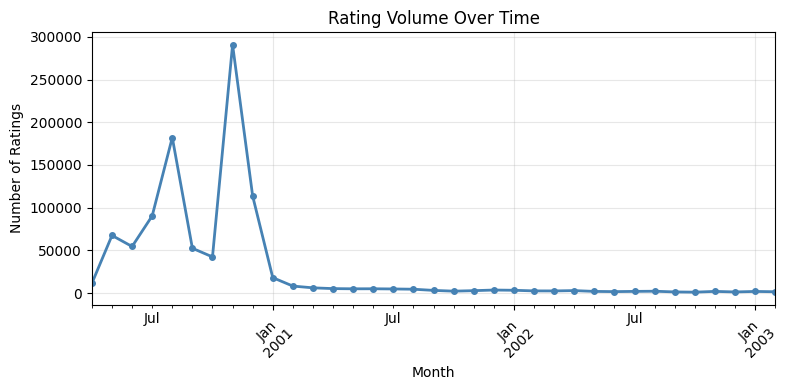

In [765]:
monthly_volume = ratings.groupby("month").size()

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

monthly_volume.plot(
    kind="line",
    marker="o",
    linewidth=2,
    markersize=4,
    color=COLOR_PRIMARY,
    ax=axis
)

axis.set_xlabel("Month")
axis.set_ylabel("Number of Ratings")
axis.set_title("Rating Volume Over Time")
axis.tick_params(
    axis="x",
    rotation=45
)
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

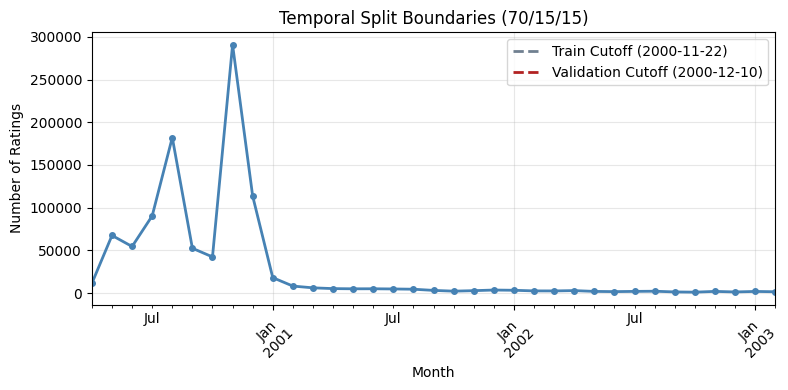

In [766]:
sorted_timestamps = ratings["timestamp"].sort_values()
total_ratings = len(sorted_timestamps)

train_cutoff_timestamp = sorted_timestamps.iloc[int(total_ratings * 0.70)]
validation_cutoff_timestamp = sorted_timestamps.iloc[int(total_ratings * 0.85)]

train_cutoff = pd.to_datetime(
    train_cutoff_timestamp,
    unit="s"
)
validation_cutoff = pd.to_datetime(
    validation_cutoff_timestamp,
    unit="s"
)

train_period = train_cutoff.to_period("M")
validation_period = validation_cutoff.to_period("M")
x_positions = list(monthly_volume.index)

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

monthly_volume.plot(
    kind="line",
    marker="o",
    linewidth=2,
    markersize=4,
    color=COLOR_PRIMARY,
    ax=axis
)

if train_period in x_positions:
    train_x = x_positions.index(train_period)
    axis.axvline(
        train_x,
        color=COLOR_SECONDARY,
        linestyle="--",
        linewidth=2,
        label=f"Train Cutoff ({train_cutoff.date()})"
    )

if validation_period in x_positions:
    validation_x = x_positions.index(validation_period)
    axis.axvline(
        validation_x,
        color=COLOR_ACCENT,
        linestyle="--",
        linewidth=2,
        label=f"Validation Cutoff ({validation_cutoff.date()})"
    )

axis.set_xlabel("Month")
axis.set_ylabel("Number of Ratings")
axis.set_title("Temporal Split Boundaries (70/15/15)")
axis.tick_params(
    axis="x",
    rotation=45
)
axis.legend()
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

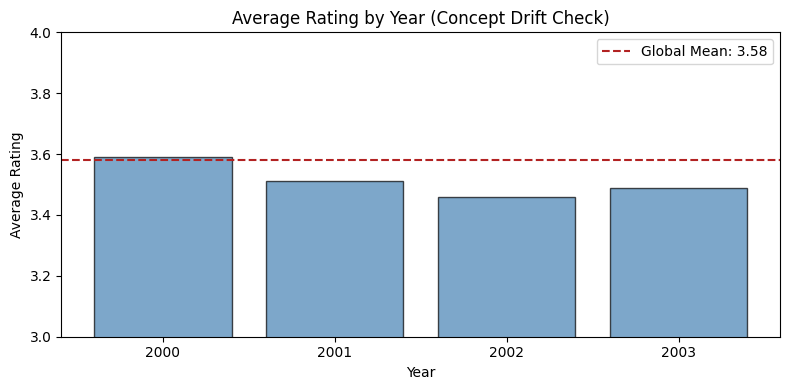

In [767]:
yearly_stats = ratings.groupby("year").agg({
    "rating": ["mean", "std", "count"]
}).round(3)
yearly_stats.columns = ["mean_rating", "std_rating", "count"]

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.bar(
    yearly_stats.index.astype(str),
    yearly_stats["mean_rating"],
    color=COLOR_PRIMARY,
    edgecolor="black",
    alpha=0.7
)
axis.axhline(
    global_mean_rating,
    color=COLOR_ACCENT,
    linestyle="--",
    label=f"Global Mean: {global_mean_rating:.2f}"
)
axis.set_xlabel("Year")
axis.set_ylabel("Average Rating")
axis.set_title("Average Rating by Year (Concept Drift Check)")
axis.set_ylim(3.0, 4.0)
axis.legend()

plt.tight_layout()
plt.show()

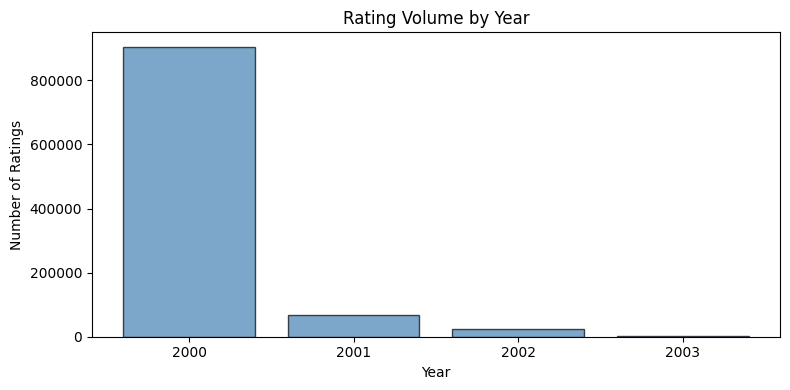

In [768]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.bar(
    yearly_stats.index.astype(str),
    yearly_stats["count"],
    color=COLOR_PRIMARY,
    edgecolor="black",
    alpha=0.7
)
axis.set_xlabel("Year")
axis.set_ylabel("Number of Ratings")
axis.set_title("Rating Volume by Year")

plt.tight_layout()
plt.show()

In [769]:
train_mask = ratings["timestamp"] < train_cutoff_timestamp
validation_mask = (ratings["timestamp"] >= train_cutoff_timestamp) & (ratings["timestamp"] < validation_cutoff_timestamp)
test_mask = ratings["timestamp"] >= validation_cutoff_timestamp

train_users = set(ratings[train_mask]["user_id"].unique())
validation_users = set(ratings[validation_mask]["user_id"].unique())
test_users = set(ratings[test_mask]["user_id"].unique())

train_items = set(ratings[train_mask]["item_id"].unique())
validation_items = set(ratings[validation_mask]["item_id"].unique())
test_items = set(ratings[test_mask]["item_id"].unique())

coverage_data = pd.DataFrame([
    {
        "Split": "Train",
        "Users": len(train_users),
        "Items": len(train_items),
        "Ratings": train_mask.sum()
    },
    {
        "Split": "Validation",
        "Users": len(validation_users),
        "Items": len(validation_items),
        "Ratings": validation_mask.sum()
    },
    {
        "Split": "Test",
        "Users": len(test_users),
        "Items": len(test_items),
        "Ratings": test_mask.sum()
    },
])

cold_start_data = pd.DataFrame([
    {"Metric": "New Users in Validation", "Count": len(validation_users - train_users)},
    {"Metric": "New Users in Test", "Count": len(test_users - train_users)},
    {"Metric": "New Items in Validation", "Count": len(validation_items - train_items)},
    {"Metric": "New Items in Test", "Count": len(test_items - train_items)},
])

In [770]:
display(coverage_data)

,Split,Users,Items,Ratings
0,Train,4870,3633,700144
1,Validation,1352,3426,150033
2,Test,1512,3482,150032


In [771]:
display(cold_start_data)

,Metric,Count
0,New Users in Validation,845
1,New Users in Test,571
2,New Items in Validation,36
3,New Items in Test,50


**Takeaway:** The time analysis supports our decision to use a time-based split for evaluation. With nearly 3 years of data and relatively stable rating behavior, we can apply a 70/15/15 temporal split without worrying that the test set originates from a different distribution. This reflects the actual situation: in production, we train on past data and predict future interactions.

The main challenge here is the cold-start problem during evaluation. There are 845 users in validation and 571 in the test group who were not part of the training data. This amounts to about 60% of validation users and 38% of test users, a considerable number that traditional collaborative filtering can't manage. For items, the issue is less severe with 36 to 50 new items but still exists. When we report model performance, we should break down the results based on whether users or items were included in the training data. Otherwise, overall metrics might conceal poor performance in cold-start situations. This temporal split is straightforward but challenging.

## Section 7: Content Analysis for Similarity Functions

In [772]:
movies["genre_list"] = movies["genres"].str.split("|")

all_genres = set()
for genres in movies["genre_list"]:
    all_genres.update(genres)

pd.DataFrame([
    {"Metric": "Number of Unique Genres", "Value": len(all_genres)},
    {"Metric": "Genres", "Value": ", ".join(sorted(all_genres))},
])

,Metric,Value
0,Number of Unique Genres,18
1,Genres,"Action, Adventure, Animation, Children's, Come..."


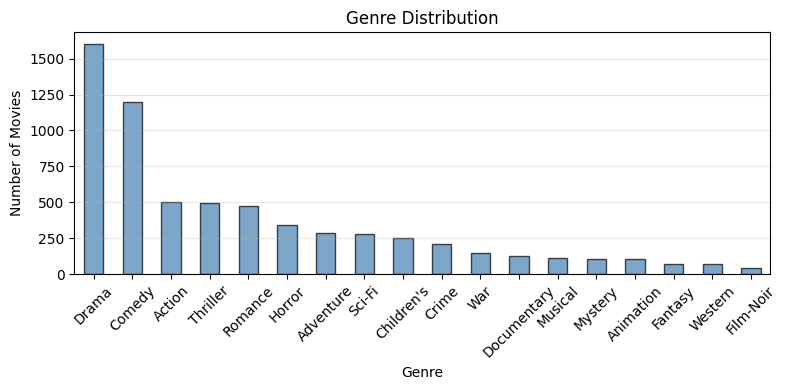

In [773]:
exploded = movies.explode("genre_list")
genre_counts = exploded["genre_list"].value_counts()

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

genre_counts.plot(
    kind="bar",
    color=COLOR_PRIMARY,
    edgecolor="black",
    alpha=0.7,
    ax=axis
)

axis.set_xlabel("Genre")
axis.set_ylabel("Number of Movies")
axis.set_title("Genre Distribution")
axis.tick_params(
    axis="x",
    rotation=45
)
axis.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

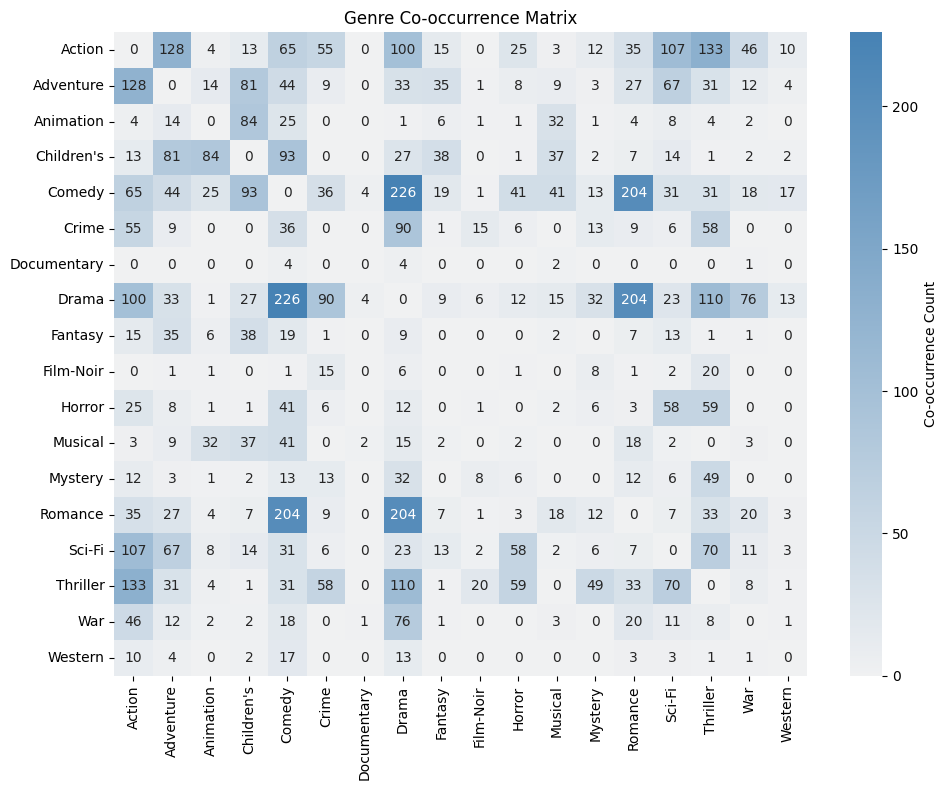

In [774]:
binarizer = MultiLabelBinarizer()
genre_matrix = binarizer.fit_transform(movies["genre_list"])
genre_names = binarizer.classes_

cooccurrence = genre_matrix.T @ genre_matrix
np.fill_diagonal(cooccurrence, 0)

cmap_primary = sns.light_palette(
    COLOR_PRIMARY,
    as_cmap=True
)

figure, axis = plt.subplots(figsize=FIGURE_SIZE_LARGE)

sns.heatmap(
    cooccurrence,
    xticklabels=genre_names,
    yticklabels=genre_names,
    cmap=cmap_primary,
    annot=True,
    fmt="d",
    cbar_kws={"label": "Co-occurrence Count"},
    ax=axis
)

axis.set_title("Genre Co-occurrence Matrix")

plt.tight_layout()
plt.show()

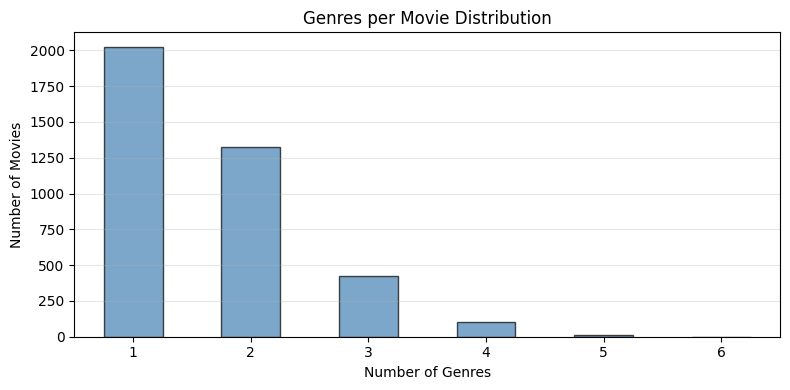

In [775]:
movies["genre_count"] = movies["genre_list"].apply(len)
genres_per_movie = movies["genre_count"].value_counts().sort_index()

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

genres_per_movie.plot(
    kind="bar",
    color=COLOR_PRIMARY,
    edgecolor="black",
    alpha=0.7,
    ax=axis
)

axis.set_xlabel("Number of Genres")
axis.set_ylabel("Number of Movies")
axis.set_title("Genres per Movie Distribution")
axis.tick_params(
    axis="x",
    rotation=0
)
axis.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

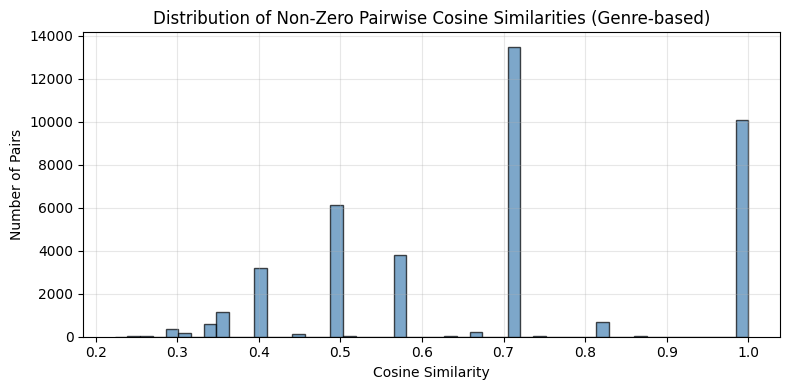

In [776]:
np.random.seed(42)
sample_indices = np.random.choice(
    len(genre_matrix),
    size=500,
    replace=False
)
sample_matrix = genre_matrix[sample_indices]

similarity_matrix = cosine_similarity(sample_matrix)
upper_triangle = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.hist(
    upper_triangle[upper_triangle > 0],
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color=COLOR_PRIMARY
)

axis.set_xlabel("Cosine Similarity")
axis.set_ylabel("Number of Pairs")
axis.set_title("Distribution of Non-Zero Pairwise Cosine Similarities (Genre-based)")
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

**Takeaway:** The genre metadata offers a solid base for content-based filtering, but it has clear limits. There are 18 genres, and most movies have 1 to 3 tags. Using binary genre vectors along with cosine similarity should create meaningful item-to-item comparisons. The co-occurrence patterns, like Action-Adventure and Comedy-Romance, show that genre relationships reflect real thematic groupings in the catalog.

However, we must recognize what genre features cannot show. Elements like tone, cinematography style, or cult status may be important to users. The strong focus on Drama and Comedy also means our content-based recommendations might favor these genres unless we address this issue. This analysis shows that genre-based content filtering is possible for this dataset, but we should not expect it to compete with collaborative methods that can identify more subtle preference patterns.

## Section 8: Latent Structure Analysis for Matrix Factorization

In [777]:
user_to_index = {user: index for index, user in enumerate(ratings["user_id"].unique())}
item_to_index = {item: index for index, item in enumerate(ratings["item_id"].unique())}

rows = ratings["user_id"].map(user_to_index)
cols = ratings["item_id"].map(item_to_index)
data = ratings["rating"].values

sparse_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(len(user_to_index), len(item_to_index))
)

pd.DataFrame([
    {"Metric": "Matrix Shape", "Value": f"{sparse_matrix.shape}"},
    {"Metric": "Non-zero Entries", "Value": f"{sparse_matrix.nnz:,}"},
    {"Metric": "Density", "Value": f"{sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]):.4%}"},
])

,Metric,Value
0,Matrix Shape,"(6040, 3706)"
1,Non-zero Entries,"1,000,209"
2,Density,4.4684%


In [778]:
component_count = 100

svd = TruncatedSVD(
    n_components=component_count,
    random_state=42
)
svd.fit(sparse_matrix)

explained_variance = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

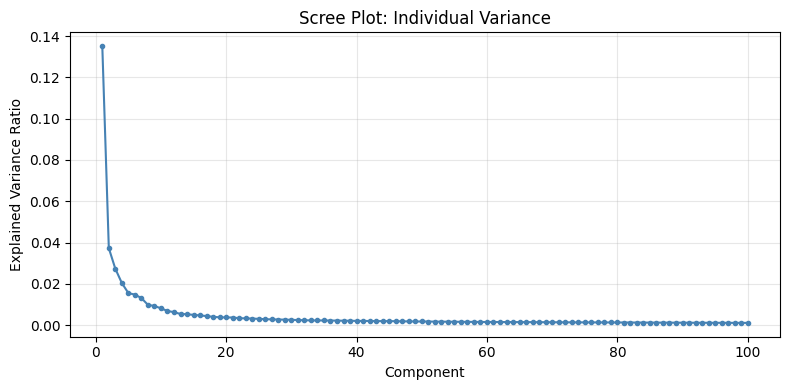

In [779]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.plot(
    range(1, component_count + 1),
    explained_variance,
    "o-",
    markersize=3,
    color=COLOR_PRIMARY
)
axis.set_xlabel("Component")
axis.set_ylabel("Explained Variance Ratio")
axis.set_title("Scree Plot: Individual Variance")
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

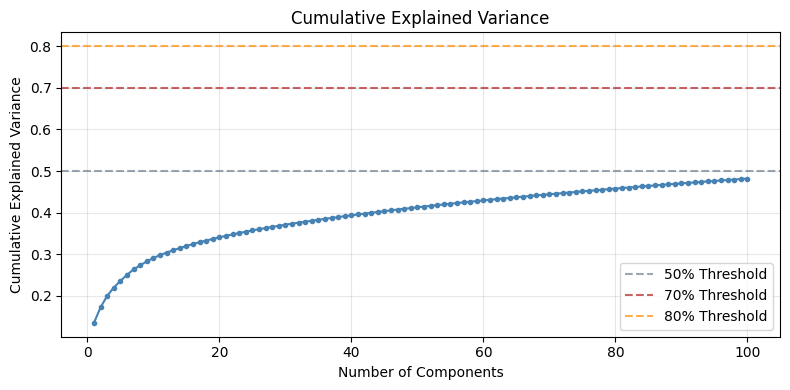

In [780]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE_STANDARD)

axis.plot(
    range(1, component_count + 1),
    cumulative_variance,
    "o-",
    markersize=3,
    color=COLOR_PRIMARY
)
axis.axhline(
    0.5,
    color=COLOR_SECONDARY,
    linestyle="--",
    alpha=0.7,
    label="50% Threshold"
)
axis.axhline(
    0.7,
    color=COLOR_ACCENT,
    linestyle="--",
    alpha=0.7,
    label="70% Threshold"
)
axis.axhline(
    0.8,
    color=COLOR_HIGHLIGHT,
    linestyle="--",
    alpha=0.7,
    label="80% Threshold"
)
axis.set_xlabel("Number of Components")
axis.set_ylabel("Cumulative Explained Variance")
axis.set_title("Cumulative Explained Variance")
axis.legend(loc="lower right")
axis.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [781]:
variance_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

threshold_results = []
for threshold in variance_thresholds:
    k = np.searchsorted(cumulative_variance, threshold) + 1
    if k <= component_count:
        threshold_results.append({"Variance Threshold": f"{threshold:.0%}", "Components Needed": k})
    else:
        threshold_results.append({"Variance Threshold": f"{threshold:.0%}", "Components Needed": f"> {component_count}"})

rate_of_change = np.diff(explained_variance)
second_derivative = np.diff(rate_of_change)
elbow_index = np.argmax(second_derivative) + 2

k_50_variance = np.searchsorted(cumulative_variance, 0.5) + 1
k_70_variance = np.searchsorted(cumulative_variance, 0.7) + 1

threshold_results.append({"Variance Threshold": "Elbow Point", "Components Needed": elbow_index})

pd.DataFrame(threshold_results)

,Variance Threshold,Components Needed
0,30%,12
1,40%,44
2,50%,> 100
3,60%,> 100
4,70%,> 100
5,80%,> 100
6,Elbow Point,2


**Takeaway:** The SVD analysis shows something significant but not surprising for sparse rating matrices: the latent structure is naturally high-dimensional. Even with 100 components, we capture less than 50% of the variance. This indicates that user preferences in this dataset are truly diverse and cannot be summarized by just a few major factors. The elbow point at just 2 components is mathematically simple and should not dictate our choice of dimensions.

For our matrix factorization experiments, including FunkSVD and ALS, this means we should expect to use a relatively high number of latent factors, possibly between 50 and 100, and rely heavily on regularization to avoid overfitting.  We will treat the latent dimension as a hyperparameter to adjust based on experimentation, using this analysis for context rather than as a strict guideline.